# 3-1장. K-최근접 이웃 회귀

K-최근접 이웃 분류는 어떤 데이터의 특성이 주어졌을 때, 그 데이터와 가장 가까운 k개의 샘플들의 레이블들 중 가장 많은 수의 레이블들로 데이터의 레이블을 분류하는 알고리즘이었다.

K-최근접 이웃 회귀는 이와 유사하게 주어진 데이터의 '예측값'을 주변 k개의 샘플들의 '값'의 평균으로 추정하는 알고리즘이다.

회귀는 두 변수의 상관관계를 분석하는 방법이다.

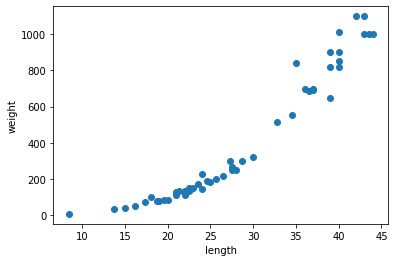

In [4]:
# 농어의 길이와 무게 준비.
import matplotlib.pyplot as plt
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

# 농어의 길이를 바탕으로 무게를 회귀한다.
# 즉, 길이와 무게라는 특성의 상관관계를 분석 (회귀) 한다.

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state = 42) # train_test_split(x, y, ...)
# train_test_split은 
# 여기서 사용하려는 인풋은 length 한개이므로 KNeighborsRegressor().fit()의 인풋인 2차원으로 만들기 위해 아래작업

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [19]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()

#print(train_target)
model.fit(train_input, train_target)

#평가
model.score(test_input, test_target)

# 결정계수 (R^2)
# 결정계수는 회귀의 평가 지표다.
# 회귀는 어떤 값을 맞추는것이 불가하기 때문에 이런 지표를 사용한다.
# 계산식: 결정계수 = 1 - (타깃-예측)^2의 합/(타깃-타깃평균)^2의 합
# 예측이 타깃에 가까울수록 1에 가깝기 때문에 회귀성능이 좋다고 볼 수 있으며, 타깃평균에 가까울수록 0에 가까워져 성능이 좋지않다고 할수있다.

0.9928094061010639

In [22]:
# 결정계수와 다른 정확도 평가
# 타깃과 예측한 값 사이의 차이를 구해보면 어느정도 예측이 벗어났는지 가늠하기 좋다
# 사이킷 런에서는 sklearn.metrics 패키지 아래 mean_absolute_error를 지원하는데
# 이는 타깃과 예측의 절댓값오차를 평균하여 반환한다.

from sklearn.metrics import mean_absolute_error

test_prediction = model.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction) # 테스트 데이터의 타깃과 모델의 예측에 대한 mae값
print(mae)
# 예측 결과가 평균적으로 19g정도 타깃과 다르다는 것을 알수있다.

19.157142857142862


In [23]:
model.score(train_input, train_target)

0.9698823289099255

In [24]:
# 위 점수는 훈련세트로 평가한 값이며, 테스트 세트로 평가했을 때보다 낮다.
# 왜 이런 문제가 발생한것일까?

# 만약 훈련세트로 평가했을 때는 점수가 좋았는데, 테스트 세트로 평가했을 때는 이보다 평가점수가 낮을 경우
# 이를 과대적합(overfitting)되었다고 말한다.

# 위 경우처럼 훈련에 사용되지않은 테스트 세트의 평가점수가 더 높거나, 테스트/훈련 세트로 평가한 결과가 모두 낮은경우
# 이를 과소적합(underfitting)되었다고 말한다.

# 즉, 위 경우는 과소적합이라고 할 수 있다.
# 발생원인은 훈련 세트와 테스트 세트의 크기가 매우 작기 때문이다.

In [26]:
# KNeighborsRegressor 모델의 n_neighbors 속성값을 줄이면 국지적인 패턴을 학습하기 때문에
# 길이특성에 대해 무게 회귀를 더욱 민감하게 학습한다.

model.n_neighbors = 3
print(train_target.shape)
model.fit(train_input, train_target)
print("test세트 평가: ", model.score(test_input, test_target))
print("train세트 평가: ", model.score(train_input, train_target))

(42,)
test세트 평가:  0.974645996398761
train세트 평가:  0.9804899950518966


In [27]:
# 위 결과처럼 두 평가에 사용된 데이터들의 결과가 비슷하여 합리적인 회귀모델이 만들어졌다고 할 수 있다.

# 키워드로 정리하는 3.1장 (K-최근접 이웃 회귀)

> 회귀

회귀는 임의의 수치를 예측하는 문제이다. 따라서 타깃값도 임의의 수치이다.

> K-최근접 이웃 회귀

K-최근접 이웃 회귀는 가장 가까운 이웃 샘플을 찾고 이 샘플들의 타깃값을 평균하여 예측값으로 한다.

> 결정계수 

$$R^2는 대표적인 회귀 문제의 성능측정 도구이다. 1에 가까울수록 좋고, 0에 가까울수록 좋지 않다.$$

$$R^2 = 1 - (타깃-예측)^2/(타깃-타깃평균)^2$$

> 과대 적합, 과소 적합

각각 오버피팅, 언더피팅이라고 한다. 과대적합은 모델의 학습에 사용된 훈련 세트의 데이터에 모델이 너무 학습되어 새로운 데이터(테스트 데이터)를 입력했을 때 훈련 세트에 기반한 추정결과를내어 성능이 좋지 않는 문제가 있다. 즉 거시적인 패턴을 감지하지 못한다고 할 수 있다.

반면 과소적합은 훈련세트와 테스트세트 둘 다로 성능을 평가했을 때 모두 좋지 않거나, 테스트 세트로 평가한 결과가 훈련 세트의 것보다 더 좋을 경우, 학습이 덜 된 모델이라고 할 수 있다. 이 경우 모델을 조금 더 복잡하게 만들면 된다. K-최근접 이웃 회귀의 경우 n_neighbors 속성을 줄여 지엽적인 두 속성간의 상관관계를 학습할 수 있도록 하면 된다.

# 핵심 패키지와 함수

```
from sklearn.neighbors import KNeighborsRegressor
```
K-최근접 이웃 회귀 모델을 만드는 클래스. n_neighbors 속성의 값을 줄이거나(모델을 더욱 복잡하게 - 언더피팅 시), 늘려서(모델을 더욱 단순하게 - 오버피팅 시) 모델을 만들 수 있다. 기본값은 5.

```
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(target, prediction)
```
회귀 결과와 타깃의 차의 절댓값들의 평균.
타깃, 예측 순으로 매개변수 전달을 해야 한다.

이와 비슷한 함수로는 mean_squared_error()가 있고, 이는 타깃과 예측을 뺀 값의 제곱의 평균을 낸다.

> 복습
```
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(length, weight, random_state=42)
!! 반드시 np.reshape으로 테스트 위 1차원의 인풋 데이터들을 2차원으로 만들어줘야 한다 !!
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)
model = KNeighborsRegressor()
model.fit(x, y)
```
